In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<ipython-input-53-6b84187601e8>:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(10,10,'Hubble Constant={:.2f}'.format(float(model_3.coef_)))


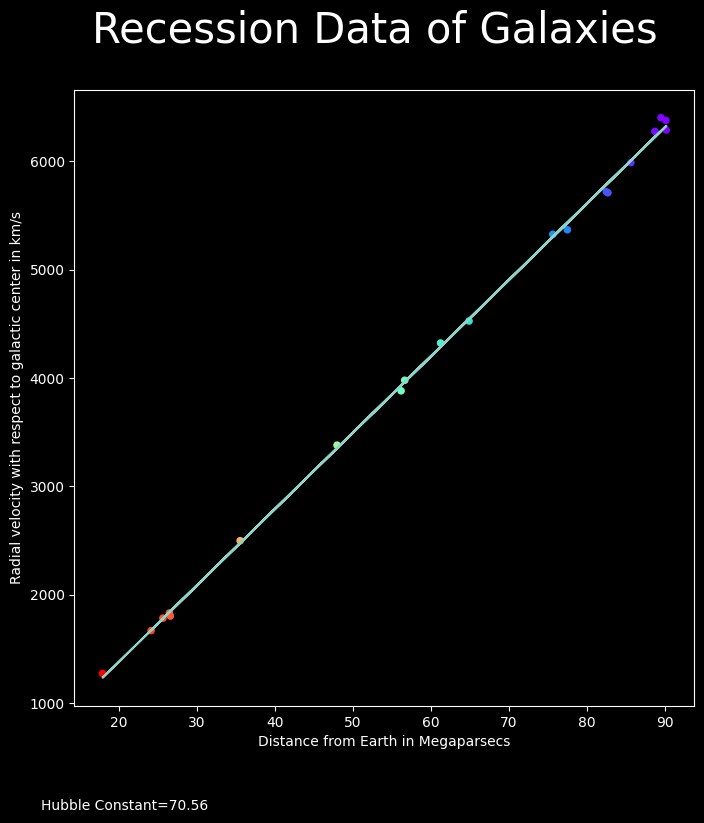

<ipython-input-53-6b84187601e8>:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(30,10,'Hubble Constant={:.2f}'.format(float(model_3_filtered_3.coef_)))


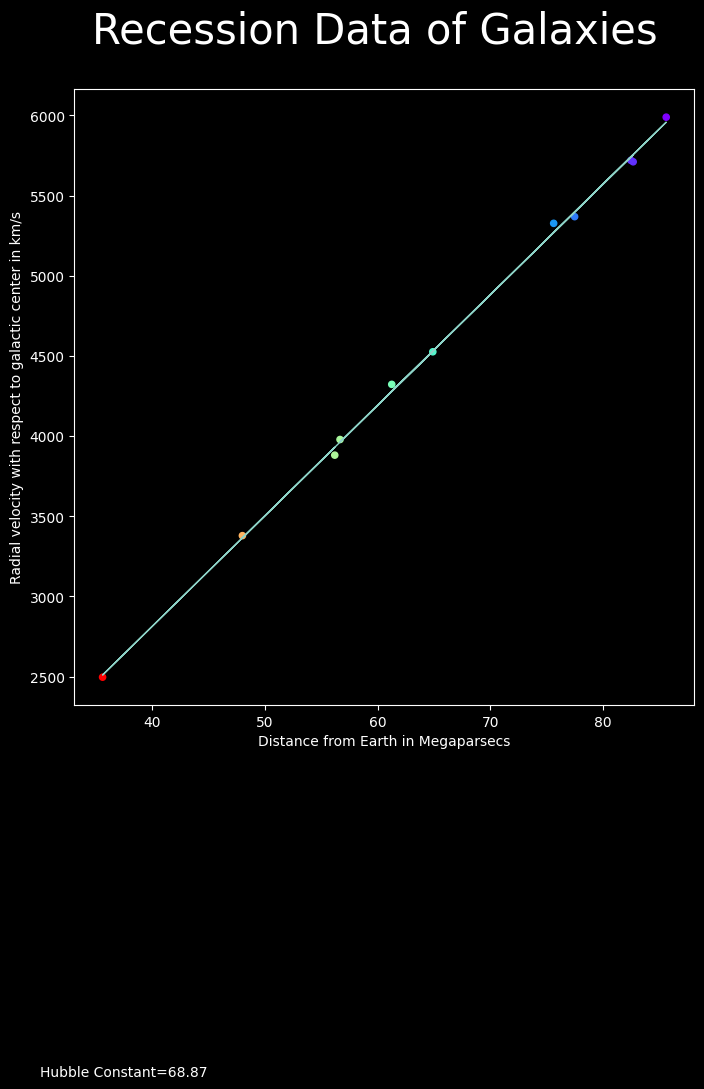

70.56365224400302
68.86765659383039


In [ ]:
data_3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/data_3.xlsx - Sheet1.csv')

data_3['Distance (Mpc)'] = pd.to_numeric(data_3['Distance (Mpc)'], errors='coerce')
data_3['Velocity (km/s)'] = pd.to_numeric(data_3['Velocity (km/s)'], errors='coerce')
data_3 = data_3.dropna(subset=['Distance (Mpc)','Velocity (km/s)'])

#assigning variables x and y for columns of data
x_3 = data_3['Distance (Mpc)']
y_3 = data_3['Velocity (km/s)']

#using parameters to take care of outliers
x_avg_3 = x_3.mean()
x_std_3 = x_3.std()
y_avg_3 = y_3.mean()
y_std_3 = y_3.std()

#lists to store non-outliers
x_3_filtered = []
y_3_filtered = []

#processing outliers
length_3 = len(x_3)
for i in range(length_3):
    if (x_3.iloc[i] <= x_avg_3 + x_std_3 and x_3.iloc[i] >= x_avg_3 - x_std_3 and
        y_3.iloc[i] <= y_avg_3 + y_std_3 and y_3.iloc[i] >= y_avg_3 - y_std_3):
        x_3_filtered.append(x_3.iloc[i])
        y_3_filtered.append(y_3.iloc[i])


#fitting the model with outliers for dataset 1
model_3 = LinearRegression()
model_3.fit(np.array(x_3).reshape(-1, 1), np.array(y_3))
y_predicted_3 = model_3.coef_ * x_3 + model_3.intercept_

#plotting data with outliers
plt.style.use("dark_background")
plt.figure(figsize = (8,8))
plt.scatter(x_3, y_3, c = x_3, cmap = 'rainbow_r', s=20)
plt.plot(x_3, y_predicted_3)
plt.suptitle("Recession Data of Galaxies", fontsize = 30)
plt.xlabel('Distance from Earth in Megaparsecs')
plt.ylabel('Radial velocity with respect to galactic center in km/s')
plt.text(10,10,'Hubble Constant={:.2f}'.format(float(model_3.coef_)))
plt.show()

#fitting the models without outliers for dataset 1
model_3_filtered_3 = LinearRegression()
model_3_filtered_3.fit(np.array(x_3_filtered).reshape(-1, 1), np.array(y_3_filtered))
y_predicted_filtered_3 = model_3_filtered_3.coef_ * x_3_filtered + model_3_filtered_3.intercept_

#plotting data without outliers
plt.style.use("dark_background")
plt.figure(figsize = (8,8))
plt.scatter(x_3_filtered, y_3_filtered, c = x_3_filtered, cmap = 'rainbow_r', s=20)
plt.plot(x_3_filtered, y_predicted_filtered_3, linewidth = 1)
plt.suptitle("Recession Data of Galaxies", fontsize = 30)
plt.xlabel('Distance from Earth in Megaparsecs')
plt.ylabel('Radial velocity with respect to galactic center in km/s')
plt.text(30,10,'Hubble Constant={:.2f}'.format(float(model_3_filtered_3.coef_)))
plt.show()

hubble_3 = model_3.coef_[0]
hubble_3_non = model_3_filtered_3.coef_[0]
print(hubble_3)
print(hubble_3_non)

Computing Mean and Variance of Hubble's Constant

In [ ]:
#computing mean and variance of Hubble's Constant
hubble_array = np.array([hubble_1,hubble_2,hubble_3]) #putting outlier output as array
hubble_array_non = np.array([hubble_1_non,hubble_2_non,hubble_3_non]) #putting non-outlier output as array

#mean and variance for outlier
hubble_mean = np.mean(hubble_array)
hubble_variance = np.var(hubble_array)

#mean and variance for non-outlier
hubble_mean_non = np.mean(hubble_array_non)
hubble_variance_non = np.var(hubble_array_non)

#printing outputs
print(f"The Mean and Variance for Hubble Constant with outlier are {np.round(hubble_mean,2)} and {np.round(hubble_variance,2)} respectively")
print(f"The Mean and Variance for Hubble Constant without outlier are {np.round(hubble_mean_non,2)} and {np.round(hubble_variance_non,2)} respectively")

The Mean and Variance for Hubble Constant with outlier are 70.23 and 0.06 respectively
The Mean and Variance for Hubble Constant without outlier are 69.72 and 0.39 respectively
